# Long-term OPE ACTG175 Simulation: Varying sample ratios

In this notebook, we compare the estimation accuracy of four estimation methods with varying sample ratios drawn independently from the historical and short-term experiment datasets.

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import importlib
import numpy as np
import pandas as pd
from pandas import DataFrame
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import check_random_state
from sklearn.preprocessing import StandardScaler

# Reload modules to get latest changes
import dataset
importlib.reload(dataset)
from dataset import ACTG175DataLoader

import estimation
importlib.reload(estimation)
run_all = estimation.run_all

In [2]:
sns.set_theme(style='white')
method_list = ["long_term_experiment", "long_term_ci", "typical_ope_ips", "typical_ope_dr", "long_term_ope"]
legend = ["Long-term Experiment (Skyline)", "Long-term CI", "OPE (IPS)", "OPE (DR)", "LOPE (Ours)"]
palette = ['tab:grey', '#FF6437', '#509BF5', '#F037A5', '#4B917D', '#FFC864', '#C87D55', '#2D46B9', '#8C1932', '#9BF0E1']
y_label_dict = {
    "se": "MSE", "bias": "Squared Bias", "variance": "Variance", "selection": "% Right Selection",
    "norm_se": "Norm-MSE", "norm_bias": "Norm-Squared Bias", "norm_variance": "Norm-Variance",
    "rel_se": "Relative MSE", "rel_bias": "Relative Squared Bias", "rel_variance": "Relative Variance", "rel_selection": "Rel-% Right Selection"
}

In [3]:
### experiment configurations for ACTG175 real data ###
n_sims = 100  # number of simulation runs (reduced for real data)
n_actions = 4  # number of treatment groups (0=historical, 1=experimental)
x_dim = 13  # feature dimension (age, wtkg, race, gender, hemo, homo, drugs, cd40, cd80, symptom, karnof, preanti, str2)
a_dim = 2  # action feature dimension
s_dim = 3  # short-term reward dimension (cd420, cd820, offtrt)

# For real data, lambda is not used in the same way as synthetic data
lambda_ = 0.5  # contribution of the short-term rewards (for comparison)
reward_type = "continuous"  # time-to-event is continuous

# Data ratios to vary independently within each treatment pool
percentages = [0.20, 0.40, 0.60, 0.80, 1.00]

In [4]:
result_df_list = []

# Load dataset once
dataset = ACTG175DataLoader(
    csv_path="Survival-Analysis-ACTG-175-main/AIDS_ClinicalTrial_GroupStudy175.csv"
)

# Count samples in each treatment group
historical_pool_size = np.sum(np.isin(dataset.a_data, [0, 1, 3]))  # trt=0,1,3 (historical/observational)
experimental_pool_size = np.sum(dataset.a_data == 2)  # trt=2 (experimental)
print(
    f"Treatment group distribution: trt=0,1,3 (Historical): {historical_pool_size}, "
    f"trt=2 (Experimental): {experimental_pool_size}"
)

# For real data, we estimate policy values from the data itself
true_value_of_baseline_policy = dataset.calc_policy_value_beta(beta=1.0)
true_value_of_new_policy = dataset.calc_policy_value_eps(k=1, eps=0.1)
is_new_policy_better = int(true_value_of_baseline_policy < true_value_of_new_policy)
is_new_policy_better = is_new_policy_better - (1 - is_new_policy_better)

print(f"baseline policy: {round(true_value_of_baseline_policy, 3)}, new policy: {round(true_value_of_new_policy, 3)}")

for ratio in percentages:
    n_data_h = int(historical_pool_size * ratio)
    n_data_e = int(experimental_pool_size * ratio)
    estimated_baseline_policy_value_list, estimated_new_policy_value_list, estimated_comparison_list = [], [], []

    for sim_idx in tqdm(range(n_sims), desc=f"ratio={int(round(100 * ratio))}%..."):
        # Generate datasets according to treatment specification:
        # D_H: Historical/observational data from trt=0,1,3
        # D_E_0: Short-term experiment data from trt=2 (baseline)
        # D_E_1: Short-term experiment data from trt=2 (new policy)
        D_H = dataset.generate_dataset(n_data=n_data_h, treatment_group="historical", baseline=True)
        D_E_0 = dataset.generate_dataset(n_data=n_data_e, treatment_group="experimental", baseline=True)
        D_E_1 = dataset.generate_dataset(n_data=n_data_e, treatment_group="experimental", baseline=False)

        estimated_values_of_baseline, estimated_values_of_new_policy, estimated_comparison = run_all(D_H, [D_E_0, D_E_1])
        estimated_baseline_policy_value_list.append(estimated_values_of_baseline)
        estimated_new_policy_value_list.append(estimated_values_of_new_policy)
        estimated_comparison_list.append(estimated_comparison)

    ## summarize results
    result_df = (
        pd.concat([
            DataFrame(estimated_baseline_policy_value_list).stack(),
            DataFrame(estimated_new_policy_value_list).stack(),
            DataFrame(estimated_comparison_list).stack(),
        ], axis=1).reset_index(1).rename(columns={"level_1": "est", 0: "base_value", 1: "value", 2: "selection"})
    )
    result_df["ratio"] = ratio
    result_df["n_data_h"] = n_data_h
    result_df["n_data_e"] = n_data_e
    result_df["true_value"] = true_value_of_new_policy
    result_df["se"] = (result_df.value - true_value_of_new_policy) ** 2
    result_df["bias"] = 0.0
    result_df["variance"] = 0.0
    result_df["selection"] *= is_new_policy_better
    result_df["selection"] = result_df["selection"] == 1

    sample_mean = DataFrame(result_df.groupby(["est"]).mean().value).reset_index()
    for est_ in sample_mean["est"]:
        estimates = result_df.loc[result_df["est"] == est_, "value"].values
        mean_estimates = sample_mean.loc[sample_mean["est"] == est_, "value"].values
        mean_estimates = np.ones_like(estimates) * mean_estimates
        result_df.loc[result_df["est"] == est_, "bias"] = (true_value_of_new_policy - mean_estimates) ** 2
        result_df.loc[result_df["est"] == est_, "variance"] = (estimates - mean_estimates) ** 2

    method_summary = (
        result_df.groupby("est")[["se", "bias", "variance", "selection"]]
        .mean()
        .rename(columns={"se": "mse", "selection": "right_selection_rate"})
    )

    weight_summary = estimation.get_importance_weight_summary(D_H, D_E_0)
    weight_rows = []
    for method in method_list:
        method_weights = weight_summary.get(method, {"baseline": None, "new_policy": None})
        weight_rows.append(
            {
                "est": method,
                "baseline_weight_mean": np.nan if method_weights["baseline"] is None else method_weights["baseline"]["mean"],
                "baseline_weight_std": np.nan if method_weights["baseline"] is None else method_weights["baseline"]["std"],
                "new_policy_weight_mean": np.nan if method_weights["new_policy"] is None else method_weights["new_policy"]["mean"],
                "new_policy_weight_std": np.nan if method_weights["new_policy"] is None else method_weights["new_policy"]["std"],
            }
        )
    weight_summary_df = pd.DataFrame(weight_rows).set_index("est")

    summary_df = method_summary.join(weight_summary_df)
    print(f"\n=== data ratio: {int(round(100 * ratio))}% (historical={n_data_h}, experimental={n_data_e}) ===")
    print(summary_df.round(4).to_string())

    result_df_list.append(result_df)

result_df = pd.concat(result_df_list).reset_index(level=0)

Loaded 2139 samples from Survival-Analysis-ACTG-175-main/AIDS_ClinicalTrial_GroupStudy175.csv
Data shapes: x=(2139, 13), a=(2139,), s=(2139, 3), r=(2139,)
Treatment group distribution: trt=0,1,3 (Historical): 1615, trt=2 (Experimental): 524
baseline policy: 0.711, new policy: 0.811


ratio=20%...: 100%|██████████| 100/100 [00:29<00:00,  3.37it/s]



=== data ratio: 20% (historical=323, experimental=104) ===
                         mse    bias  variance  right_selection_rate  baseline_weight_mean  baseline_weight_std  new_policy_weight_mean  new_policy_weight_std
est                                                                                                                                                           
long_term_ci          0.0127  0.0125    0.0003                  0.51                   NaN                  NaN                     NaN                    NaN
long_term_experiment  0.0065  0.0061    0.0004                  0.56                   NaN                  NaN                     NaN                    NaN
long_term_ope         0.0149  0.0147    0.0002                  0.81                   1.0                  0.0                  1.0744                 0.2035
typical_ope_dr        0.0147  0.0145    0.0002                  0.71                   1.0                  0.0                  1.3444          

ratio=40%...: 100%|██████████| 100/100 [00:48<00:00,  2.05it/s]



=== data ratio: 40% (historical=646, experimental=209) ===
                         mse    bias  variance  right_selection_rate  baseline_weight_mean  baseline_weight_std  new_policy_weight_mean  new_policy_weight_std
est                                                                                                                                                           
long_term_ci          0.0130  0.0128    0.0002                  0.45                   NaN                  NaN                     NaN                    NaN
long_term_experiment  0.0066  0.0064    0.0002                  0.43                   NaN                  NaN                     NaN                    NaN
long_term_ope         0.0134  0.0133    0.0001                  0.82                   1.0                  0.0                  1.1137                 0.2151
typical_ope_dr        0.0139  0.0138    0.0001                  0.51                   1.0                  0.0                  1.3427          

...


=== data ratio: 60% (historical=969, experimental=314) ===
                         mse    bias  variance  right_selection_rate  baseline_weight_mean  baseline_weight_std  new_policy_weight_mean  new_policy_weight_std
est                                                                                                                                                           
long_term_ci          0.0130  0.0129    0.0001                  0.53                   NaN                  NaN                     NaN                    NaN
long_term_experiment  0.0062  0.0062    0.0001                  0.52                   NaN                  NaN                     NaN                    NaN
long_term_ope         0.0124  0.0123    0.0000                  0.96                   1.0                  0.0                  1.1055                 0.2322
typical_ope_dr        0.0133  0.0133    0.0000                  0.33                   1.0                  0.0                  1.3198          

ratio=80%...: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]



=== data ratio: 80% (historical=1292, experimental=419) ===
                         mse    bias  variance  right_selection_rate  baseline_weight_mean  baseline_weight_std  new_policy_weight_mean  new_policy_weight_std
est                                                                                                                                                           
long_term_ci          0.0129  0.0129    0.0000                  0.43                   NaN                  NaN                     NaN                    NaN
long_term_experiment  0.0062  0.0061    0.0000                  0.53                   NaN                  NaN                     NaN                    NaN
long_term_ope         0.0117  0.0117    0.0000                  1.00                   1.0                  0.0                   1.127                 0.2281
typical_ope_dr        0.0130  0.0130    0.0000                  0.26                   1.0                  0.0                   1.333         

ratio=100%...: 100%|██████████| 100/100 [01:36<00:00,  1.03it/s]



=== data ratio: 100% (historical=1615, experimental=524) ===
                         mse    bias  variance  right_selection_rate  baseline_weight_mean  baseline_weight_std  new_policy_weight_mean  new_policy_weight_std
est                                                                                                                                                           
long_term_ci          0.0125  0.0125       0.0                  0.11                   NaN                  NaN                     NaN                    NaN
long_term_experiment  0.0061  0.0061       0.0                  0.22                   NaN                  NaN                     NaN                    NaN
long_term_ope         0.0121  0.0121       0.0                  1.00                   1.0                  0.0                  1.1137                 0.2235
typical_ope_dr        0.0133  0.0133       0.0                  0.28                   1.0                  0.0                  1.3269        

## Visualization

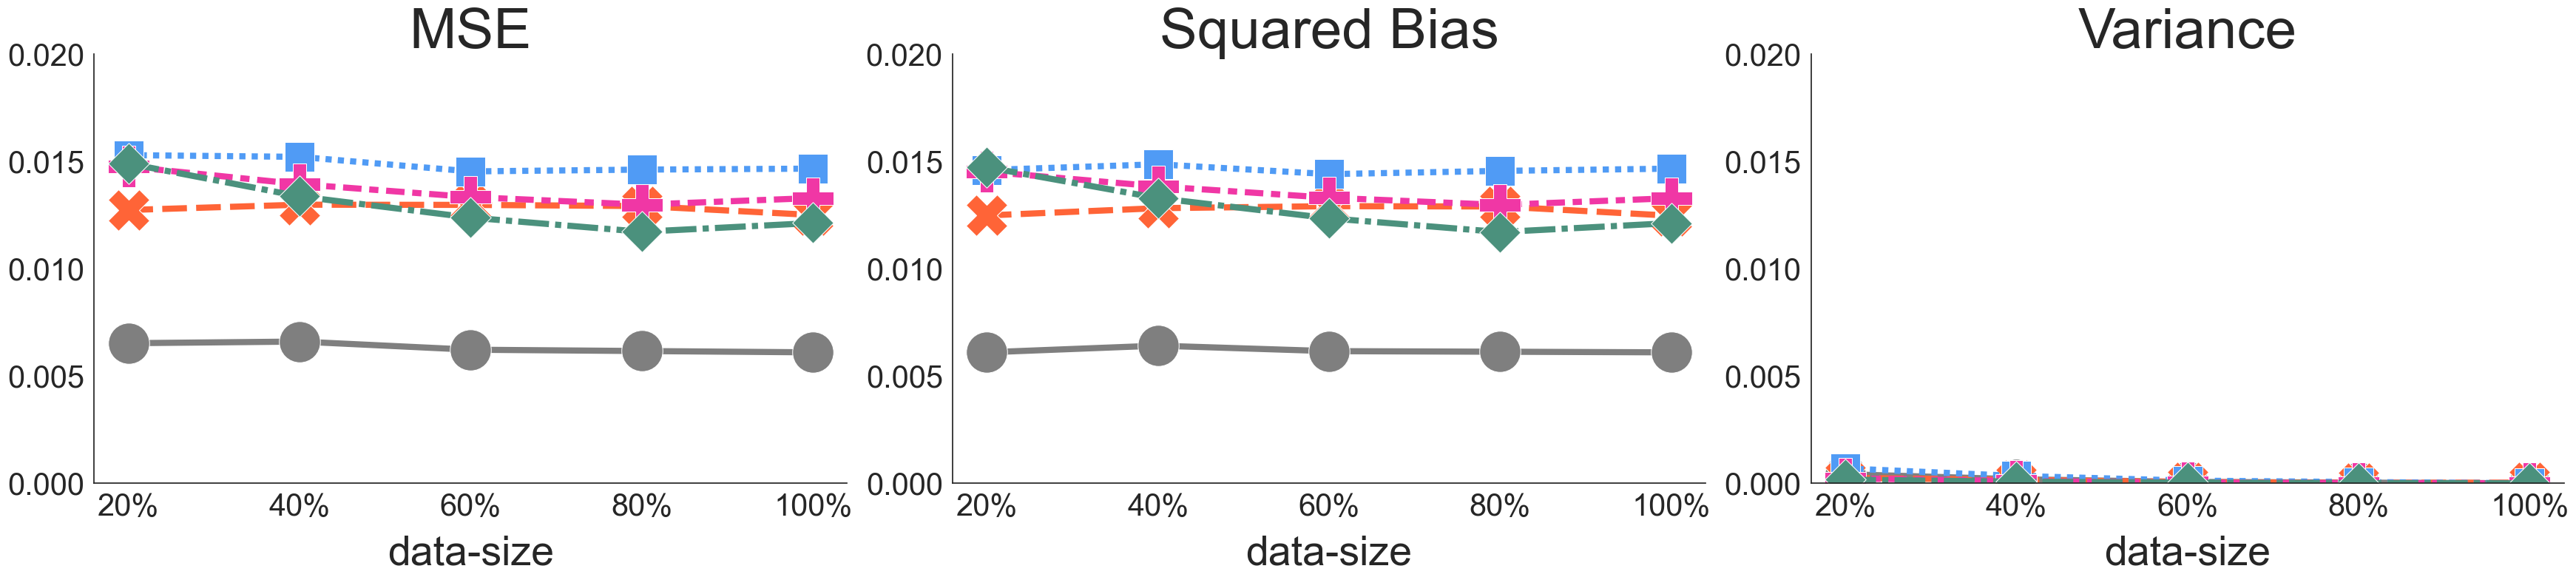

In [ ]:
fig, ax_list = plt.subplots(1, 3, figsize=(35, 8), tight_layout=True)
for i, y in enumerate(["se", "bias", "variance"]):
    ax = ax_list[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    sns.lineplot(
        markers=True,
        markersize=40,
        linewidth=6,
        legend=False,
        style="est",
        x="ratio",
        y=y,
        hue="est",
        ax=ax,
        ci=None,
        palette=palette,
        data=result_df,
    )
    ax.set_title(y_label_dict[y], fontsize=55)
    # yaxis
    ax.set_ylabel("")
    if i == 3:
        ax.set_ylim(0.8, 1.03)
    else:
        ax.set_ylim(0.0, 0.0175)
    ax.tick_params(axis="y", labelsize=30)
    # xaxis
    ax.set_xlabel("data-size", fontsize=40)
    ax.set_xticks(percentages)
    ax.set_xticklabels([f"{int(p * 100)}%" for p in percentages], fontsize=30)
    ax.xaxis.set_label_coords(0.5, -0.12)